# 🚧 Road Damage Detection using YOLOv8

### 🔍 Detecting Cracks, Potholes & Road Conditions using AI

## 📌 Project Overview
This project detects road damages like cracks and potholes using YOLOv8.

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00a 0:00:01


In [2]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 📂 Dataset
RDD 2022 dataset with labeled images and bounding boxes.

In [3]:
base_path = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"

print(os.listdir(base_path))
print(os.listdir(base_path + "/train"))
print(os.listdir(base_path + "/val"))

['val', 'test', 'train']
['labels', 'images']
['labels', 'images']


In [4]:
data_yaml = f"""
path: {base_path}

train: train/images
val: val/images

names:
  0: crack
  1: pothole
  2: normal
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created ✅")

data.yaml created ✅


## 🤖 Model
Using YOLOv8 for object detection.

In [5]:
model = YOLO("yolov8n.pt")  # fast + good for hackathon 

In [ ]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=30,      
    imgsz=640,     
    batch=16 ,
    patience=10  
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pers

In [13]:
!ls runs/detect/train/weights

best.pt  last.pt


## 📊 Results
Below are detection outputs:

In [14]:
results = model.predict(
    source="/kaggle/input/datasets/pragadeeshwarirr/road-image/road.jpg",
    conf=0.25,
    save=True
)


image 1/1 /kaggle/input/datasets/pragadeeshwarirr/road-image/road.jpg: 448x640 2 cracks, 8.5ms
Speed: 4.1ms preprocess, 8.5ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict


(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

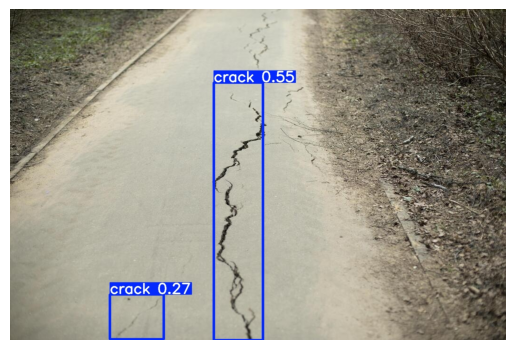

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/road.jpg")
plt.imshow(img)
plt.axis('off')

In [22]:
results = model.predict(
    source="/kaggle/input/datasets/pragadeeshwarirr/road-image3/road-hole.webp",
    conf=0.05,
    save=True
)


image 1/1 /kaggle/input/datasets/pragadeeshwarirr/road-image3/road-hole.webp: 448x640 2 potholes, 6.1ms
Speed: 2.2ms preprocess, 6.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict


(np.float64(-0.5), np.float64(799.5), np.float64(531.5), np.float64(-0.5))

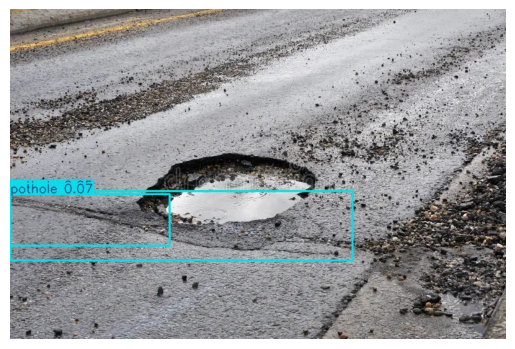

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/road-hole.jpg")
plt.imshow(img)
plt.axis('off')

In [19]:
import shutil

shutil.copy(
    "runs/detect/train/weights/best.pt",
    "/kaggle/working/road_damage_detection_model.pt"
)

'/kaggle/working/road_damage_detection_model.pt'

## ✅ Conclusion
The model successfully detects road damage.